<b><u>Machine Learning–Based Credit Risk Assessment and Loan Default Prediction System

Sample Data:
    Age   Income  LoanAmount  CreditScore  LoanTerm  EmploymentYears  \
0   59  1004034      466978          598        24               28   
1   49   565464      674771          595        24               21   
2   35   813089      573886          502        24               15   
3   63   488075      583884          360        24                3   
4   28   294377      284627          613        60               19   

   DebtRatio  Default  
0   0.713479        1  
1   0.314630        1  
2   0.572644        1  
3   0.677159        1  
4   0.853023        1  

Model Accuracy: 83.73 %

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.59      0.64        94
           1       0.87      0.92      0.89       281

    accuracy                           0.84       375
   macro avg       0.79      0.75      0.77       375
weighted avg       0.83      0.84      0.83       375



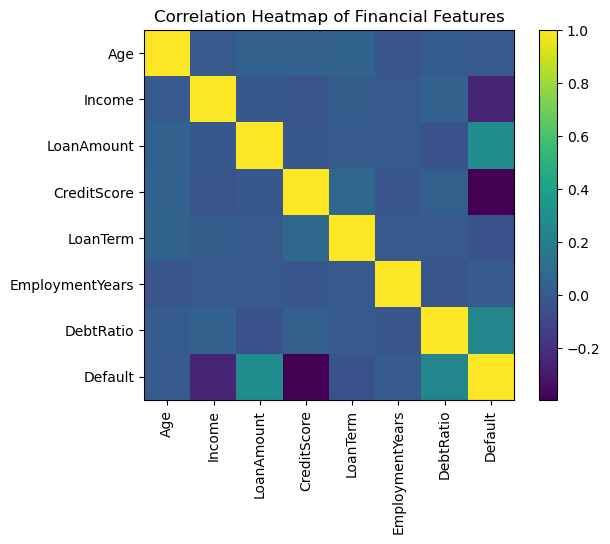

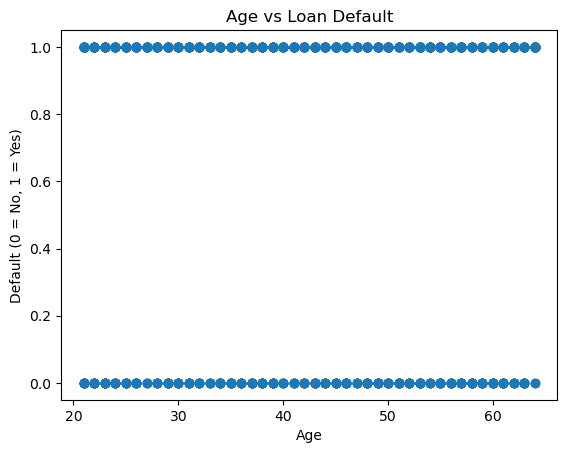

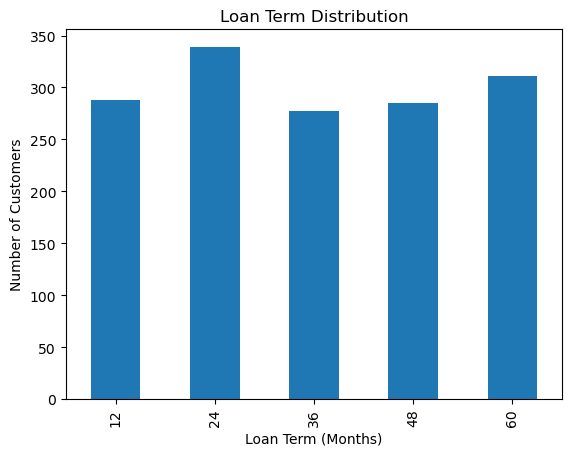

<Figure size 640x480 with 0 Axes>

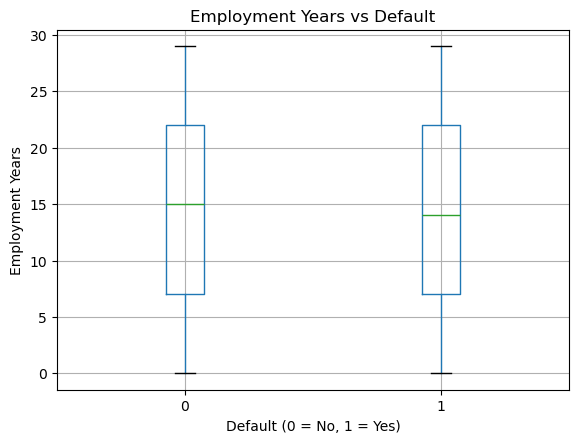

<Figure size 640x480 with 0 Axes>

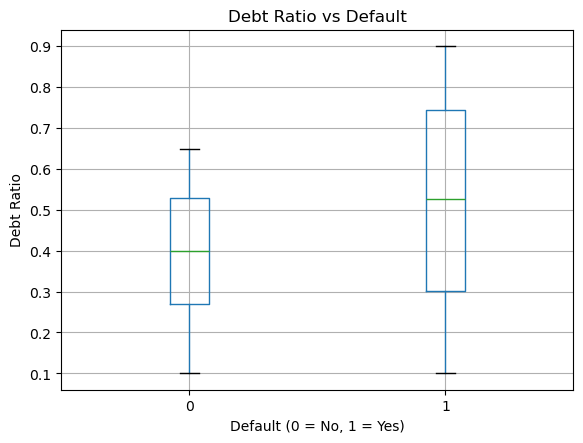

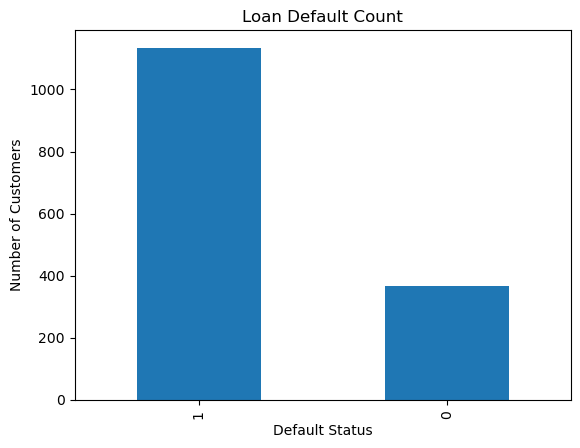

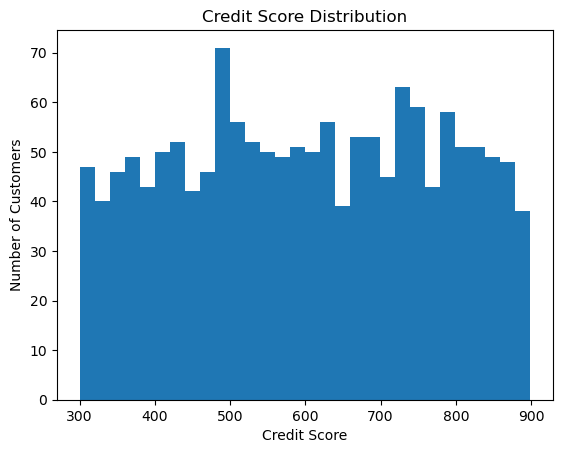

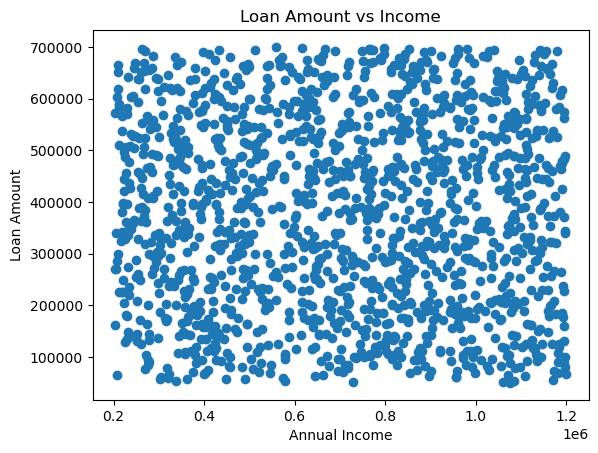

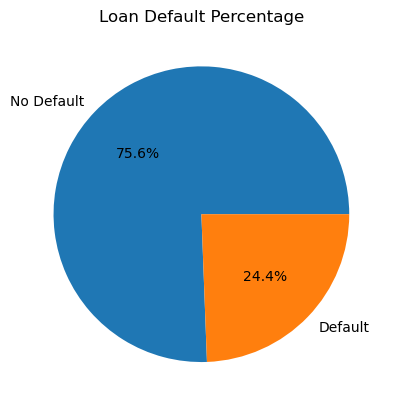

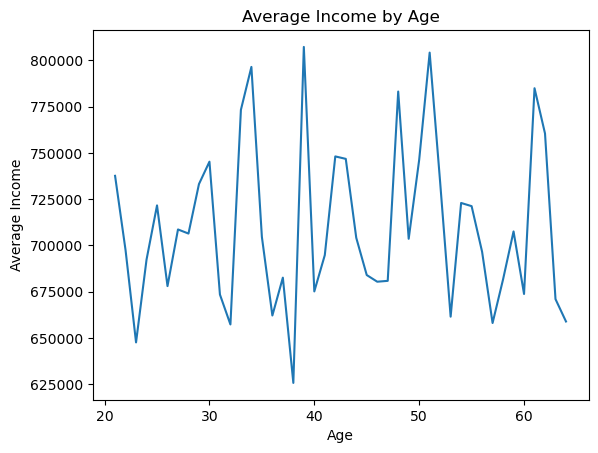

In [1]:
# ============================================================
# CAPSTONE PROJECT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------------------------
# 1. Synthetic Data Generation (No CSV Files Used)
# ------------------------------------------------------------

np.random.seed(42)
samples = 1500

age = np.random.randint(21, 65, samples)
income = np.random.randint(200000, 1200000, samples)
loan_amount = np.random.randint(50000, 700000, samples)
credit_score = np.random.randint(300, 900, samples)
loan_term = np.random.choice([12, 24, 36, 48, 60], samples)
employment_years = np.random.randint(0, 30, samples)
debt_ratio = np.random.uniform(0.1, 0.9, samples)

# Default logic (financial risk pattern)
default = (
    (credit_score < 550).astype(int) |
    (loan_amount > income * 0.6).astype(int) |
    (debt_ratio > 0.65).astype(int)
)

data = pd.DataFrame({
    "Age": age,
    "Income": income,
    "LoanAmount": loan_amount,
    "CreditScore": credit_score,
    "LoanTerm": loan_term,
    "EmploymentYears": employment_years,
    "DebtRatio": debt_ratio,
    "Default": default
})

print("Sample Data:\n", data.head())

# ------------------------------------------------------------
# 2. Machine Learning Model
# ------------------------------------------------------------

X = data.drop("Default", axis=1)
y = data["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("\nModel Accuracy:", round(accuracy_score(y_test, predictions) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, predictions))

# ------------------------------------------------------------
# 3. DATA VISUALIZATIONS (ALL REQUIRED CHARTS)
# ------------------------------------------------------------

# 1. Correlation Heatmap (VERY IMPORTANT FOR VIVA)
plt.figure()
correlation = data.corr()
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap of Financial Features")
plt.show()

# 2. Age vs Default (Scatter Plot)
plt.figure()
plt.scatter(data["Age"], data["Default"])
plt.xlabel("Age")
plt.ylabel("Default (0 = No, 1 = Yes)")
plt.title("Age vs Loan Default")
plt.show()

# 3. Loan Term Distribution (Bar Chart)
plt.figure()
data["LoanTerm"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Number of Customers")
plt.title("Loan Term Distribution")
plt.show()

# 4. Employment Years vs Default (Box Plot)
plt.figure()
data.boxplot(column="EmploymentYears", by="Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Employment Years")
plt.title("Employment Years vs Default")
plt.suptitle("")
plt.show()

# 5. Debt Ratio vs Default (Box Plot)
plt.figure()
data.boxplot(column="DebtRatio", by="Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Debt Ratio")
plt.title("Debt Ratio vs Default")
plt.suptitle("")
plt.show()

# 6. Default Count (Bar Chart)
plt.figure()
data["Default"].value_counts().plot(kind="bar")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.title("Loan Default Count")
plt.show()

# 7. Credit Score Distribution (Histogram)
plt.figure()
plt.hist(data["CreditScore"], bins=30)
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.title("Credit Score Distribution")
plt.show()

# 8. Loan Amount vs Income (Scatter Plot)
plt.figure()
plt.scatter(data["Income"], data["LoanAmount"])
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.title("Loan Amount vs Income")
plt.show()

# 9. PIE CHART – Default vs Non-Default
default_counts = data["Default"].value_counts()

plt.figure()
plt.pie(default_counts, labels=["No Default", "Default"], autopct="%1.1f%%")
plt.title("Loan Default Percentage")
plt.show()

# 10. LINE GRAPH – Average Income by Age
avg_income_by_age = data.groupby("Age")["Income"].mean()

plt.figure()
plt.plot(avg_income_by_age.index, avg_income_by_age.values)
plt.xlabel("Age")
plt.ylabel("Average Income")
plt.title("Average Income by Age")
plt.show()

